In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
plt.style.use("../../plots.mplstyle")

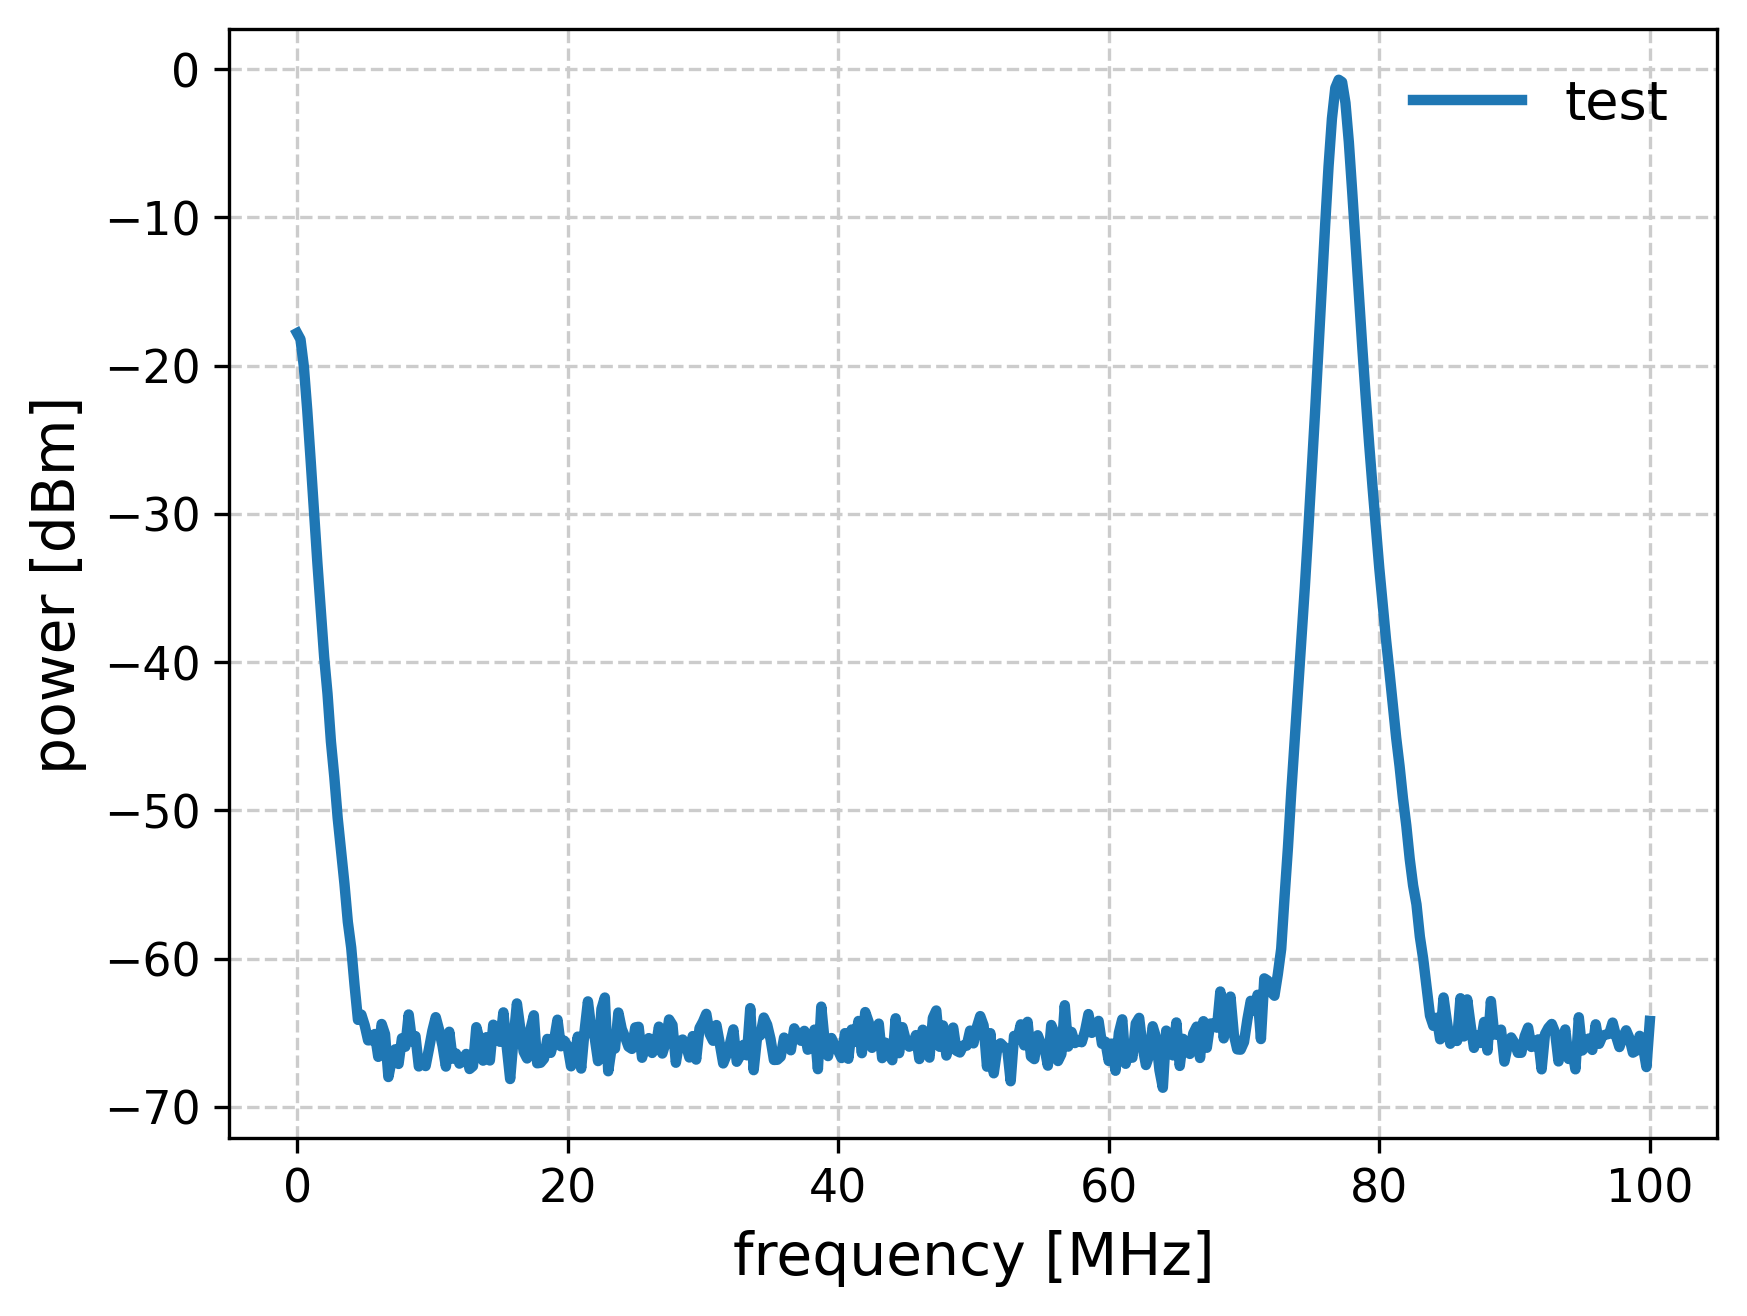

In [3]:
save_dir = Path("./captures")

filename = "output_77_mhz_neg_1_dbm.csv"
filepath = save_dir / filename

loaded = np.loadtxt(filepath, delimiter=",", skiprows=1)

freq = loaded[:, 0]
dbm = loaded[:, 1]

fig, ax = plt.subplots(dpi=300)
ax.plot(freq / 1e6, dbm, label="test")
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("power [dBm]")
# ax.set_ylim([-70, -20])
plt.legend()

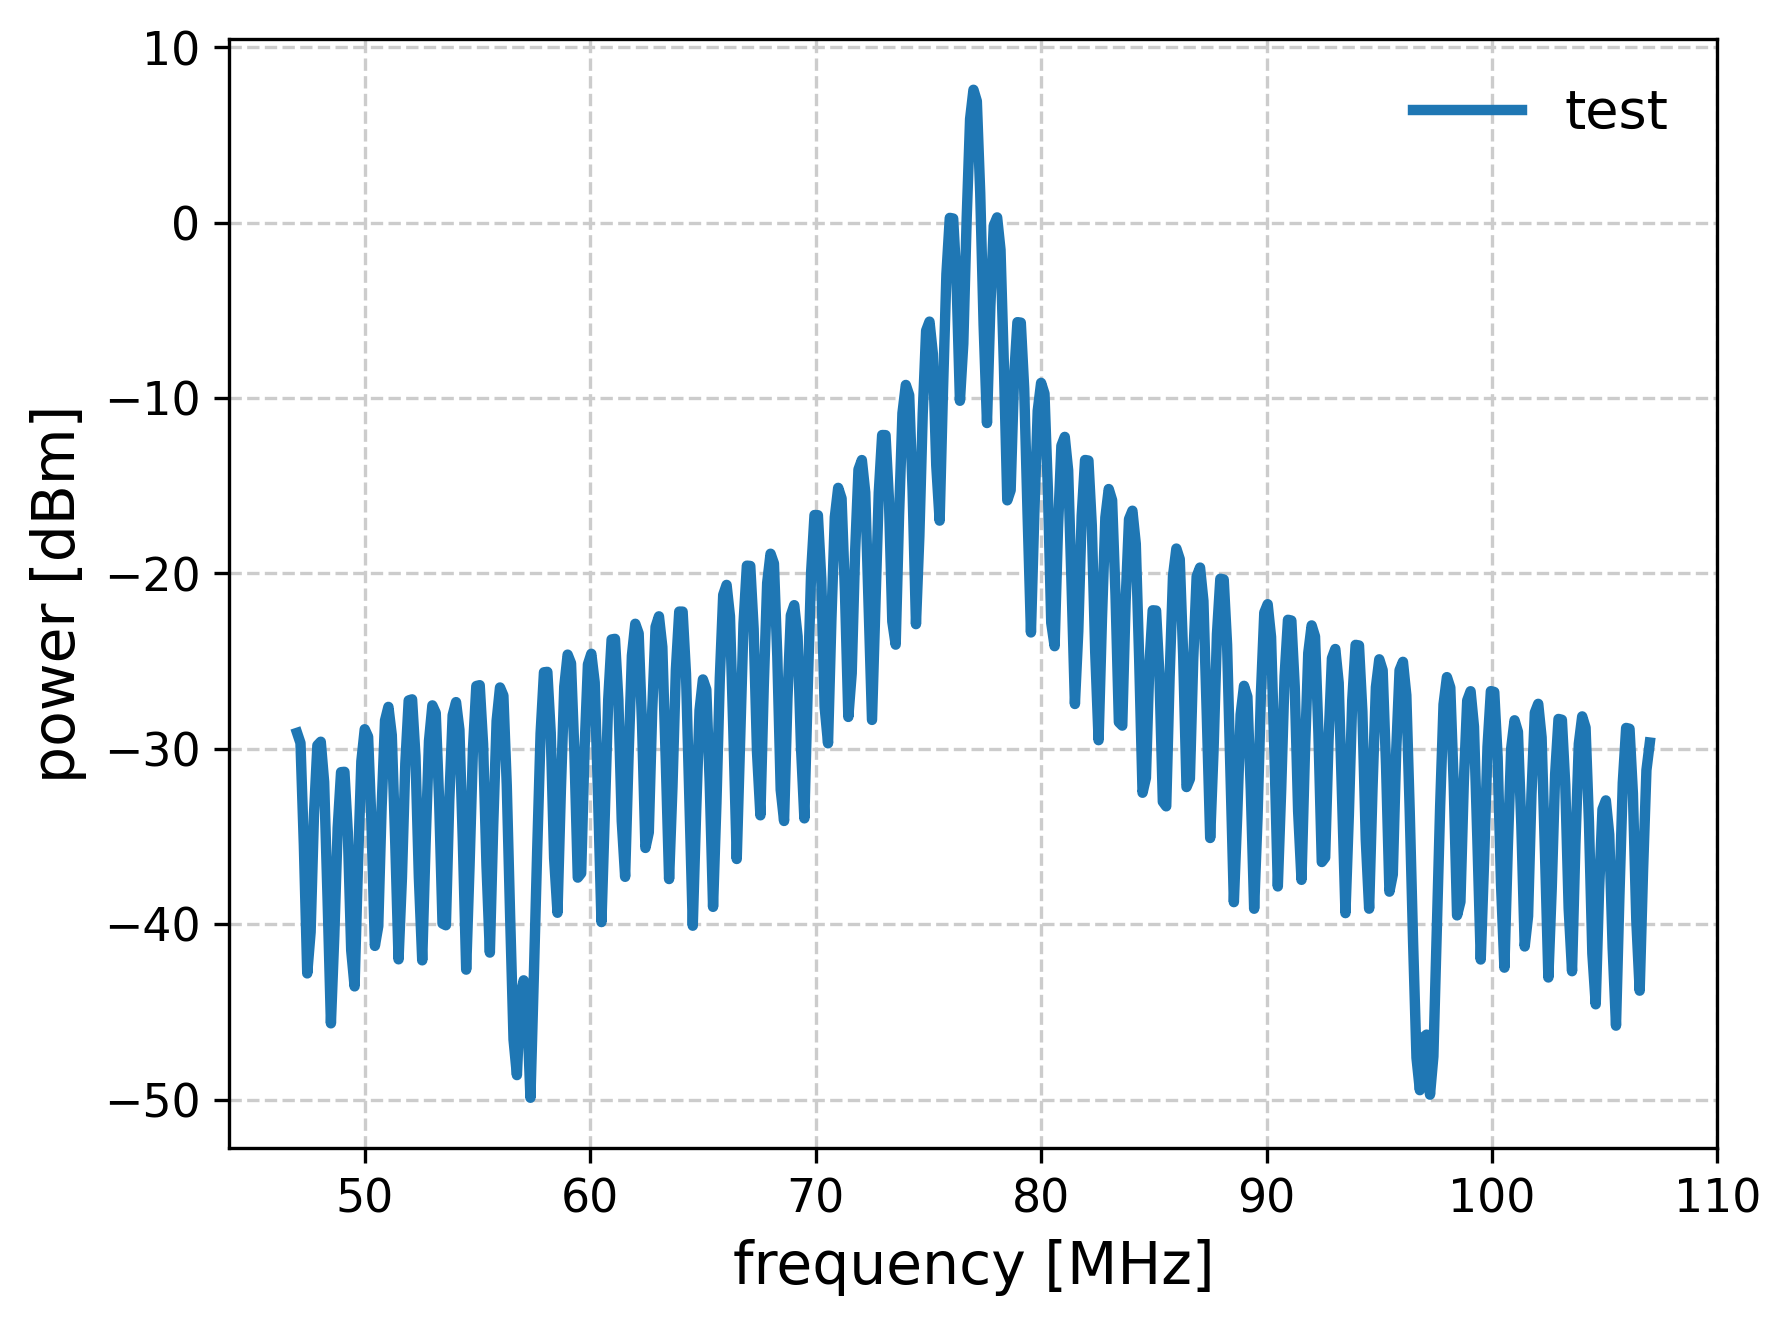

In [37]:
save_dir = Path("./captures")

filename = "esa_trace.csv"
filepath = save_dir / filename

loaded = np.loadtxt(filepath, delimiter=",", skiprows=1)

freq = loaded[:, 0]
dbm = loaded[:, 1]

fig, ax = plt.subplots(dpi=300)
ax.plot(freq / 1e6, dbm, label="test")
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("power [dBm]")
# ax.set_ylim([-70, -20])
plt.legend()

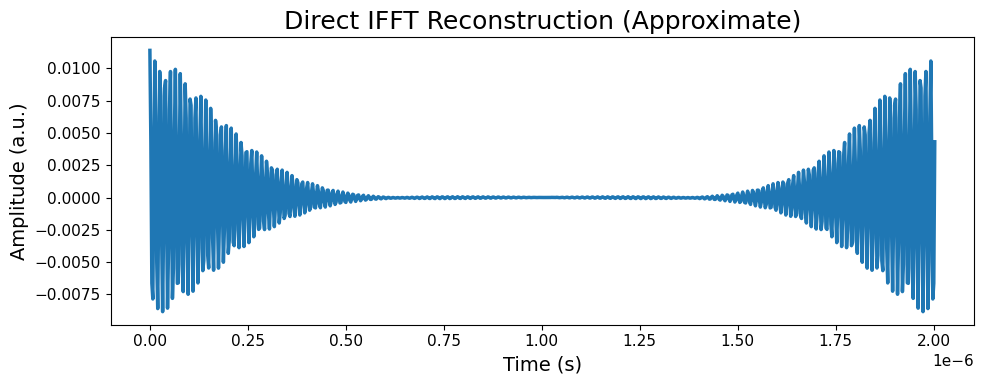

In [7]:
freqs_hz = freq
amps_dbm = dbm
freqs = np.array(freqs_hz)
amps_dbm = np.array(amps_dbm)

# -----------------------------
# Convert dBm -> linear amplitude
# (magnitude only, no phase)
# -----------------------------
amps = np.sqrt(10**(amps_dbm / 10))

# -----------------------------
# Sort by frequency (important)
# -----------------------------
idx = np.argsort(freqs)
freqs = freqs[idx]
amps = amps[idx]

# -----------------------------
# Interpolate onto uniform grid
# -----------------------------
N = len(freqs)
f_uniform = np.linspace(freqs[0], freqs[-1], N)
X = np.interp(f_uniform, freqs, amps)

# -----------------------------
# Assume zero phase
# -----------------------------
X = X.astype(complex)

# -----------------------------
# Build full symmetric spectrum
# (Hermitian symmetry for real signal)
# -----------------------------
X_full = np.concatenate([X, np.conjugate(X[::-1])])

# -----------------------------
# IFFT to time domain
# -----------------------------
x_time = np.fft.ifft(X_full)
x_time = np.real(x_time)

# -----------------------------
# Time axis
# -----------------------------
df = f_uniform[1] - f_uniform[0]
fs = 2 * (f_uniform[-1] - f_uniform[0])  # approx Nyquist
t = np.arange(len(x_time)) / fs

# -----------------------------
# Plot result
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(t, x_time)
plt.title("Direct IFFT Reconstruction (Approximate)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.grid()
plt.tight_layout()
plt.show()